# 02 - CAE-CNNLoc 2D-Temporal: entrenamiento y evaluación

Adaptación de la arquitectura **CAE-CNNLoc** (Kargar-Barzi et al., 2024) al caso WiFi RTT con cuatro APs.
Cada muestra de entrada es una matriz fingerprint $\mathbf{M} \in \mathbb{R}^{4 \times N}$ (filas: APs ordenados por MAC; columnas: $N$ medidas RTT consecutivas).

## Estructura del notebook

1. Configuración y carga de datos.
2. **Corrida rápida** (1 semilla, pocas épocas, `POCO#STANDING` como entrenamiento) para verificar que la red converge.
3. **Corrida completa** (5 semillas × 4 subsets de entrenamiento) — habilitada con un toggle.
4. Persistencia de resultados en `results/02_cnnloc_*.csv`.

In [1]:
import os
import sys
import time
from pathlib import Path

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print('TF', tf.__version__, '| GPUs:', tf.config.list_physical_devices('GPU'))

TF 2.19.1 | GPUs: []


In [2]:
from cnnloc_rtt.data import (
    load_full_dataset,
    build_4xN_for_all_subsets,
    normalize_train_test,
)
from cnnloc_rtt.models import CAECNNLocConfig
from cnnloc_rtt.train import TrainConfig, train_one_seed, train_multiseed
from cnnloc_rtt.eval import evaluate_on_subsets, aggregate_results
from cnnloc_rtt.utils import set_global_seed, summary_stats, aggregate_seed_stats

N_WINDOW = 16
STRIDE = 1
MODEL_CFG = CAECNNLocConfig(n_aps=4, n_window=N_WINDOW)

# === Toggle this to switch between quick check and full run ===
FULL_RUN = False  # set to True for the final 5-seeds x 4-train-subsets run

if FULL_RUN:
    SEEDS = [0, 1, 2, 3, 4]
    TRAIN_SUBSET_KEYS = ['POCO#STANDING', 'POCO#TRIPOD', 'SAMSUNG#STANDING', 'SAMSUNG#TRIPOD']
    TRAIN_CFG = TrainConfig(
        pretrain_epochs=60, finetune_epochs=80, batch_size=64,
        val_split=0.2, early_stopping_patience=12, verbose=0,
    )
else:
    SEEDS = [0]
    TRAIN_SUBSET_KEYS = ['POCO#STANDING']
    TRAIN_CFG = TrainConfig(
        pretrain_epochs=20, finetune_epochs=30, batch_size=64,
        val_split=0.2, early_stopping_patience=8, verbose=0,
    )

print('FULL_RUN =', FULL_RUN, '| seeds =', SEEDS, '| train subsets =', TRAIN_SUBSET_KEYS)
print('TrainConfig:', TRAIN_CFG)

FULL_RUN = False | seeds = [0] | train subsets = ['POCO#STANDING']
TrainConfig: TrainConfig(pretrain_epochs=20, finetune_epochs=30, batch_size=64, val_split=0.2, early_stopping_patience=8, verbose=0)


In [3]:
ds = load_full_dataset()
matrices = build_4xN_for_all_subsets(ds, n_window=N_WINDOW, stride=STRIDE)
for k, (X, Y) in matrices.items():
    print(f'  {k:<22s} -> X={X.shape}, Y={Y.shape}')

C:\TFG\codigo\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


  POCO#STANDING          -> X=(3496, 4, 16, 1), Y=(3496, 2)
  POCO#TRIPOD            -> X=(3219, 4, 16, 1), Y=(3219, 2)
  SAMSUNG#STANDING       -> X=(3413, 4, 16, 1), Y=(3413, 2)
  SAMSUNG#TRIPOD         -> X=(3425, 4, 16, 1), Y=(3425, 2)


## Bucle de entrenamiento

Para cada subset de entrenamiento:

1. Normalizamos las matrices (media/desviación calculadas solo en el set de entrenamiento).
2. Para cada semilla, ejecutamos las dos fases (CAE + regresor) con early stopping.
3. Evaluamos sobre los **otros tres subsets** (cross-device/cross-pose) y sobre el propio (auto-evaluación informativa).
4. Acumulamos los resultados en un único DataFrame largo.

In [4]:
all_rows = []
histories = []

for train_key in TRAIN_SUBSET_KEYS:
    print(f'\n{"="*72}\nTraining on {train_key}\n{"="*72}')
    X_train, Y_train = matrices[train_key]
    others = {k: v[0] for k, v in matrices.items() if k != train_key}
    X_train_n, others_n, norm = normalize_train_test(X_train, others)
    print(f'  Normalisation: mean={norm["mean"]:.3f}, std={norm["std"]:.3f}')
    eval_subsets = {train_key: (X_train_n, Y_train)}
    eval_subsets.update({k: (others_n[k], matrices[k][1]) for k in others_n})

    for seed in SEEDS:
        t0 = time.time()
        regressor, encoder, history = train_one_seed(
            X_train_n, Y_train, seed, MODEL_CFG, TRAIN_CFG,
            log_callback=lambda m: print('   ', m),
        )
        elapsed = time.time() - t0
        print(f'  seed={seed} | training elapsed: {elapsed:.1f} s | '
              f'pretrain min val loss = {min(history.pretrain_val_loss):.3f} | '
              f'finetune min val loss = {min(history.finetune_val_loss):.3f}')
        df_seed = evaluate_on_subsets(regressor, eval_subsets, train_key,
                                       method_name='CAE-CNNLoc-2D', seed=seed)
        df_seed['n_window'] = N_WINDOW
        all_rows.append(df_seed)
        histories.append((train_key, seed, history))

df_cnn = pd.concat(all_rows, ignore_index=True)
df_cnn.to_csv(RESULTS / '02_cnnloc_results.csv', index=False)
print(f'\nSaved {len(df_cnn)} rows to results/02_cnnloc_results.csv')


Training on POCO#STANDING
  Normalisation: mean=11.689, std=7.799


    [seed=0] Phase 1 (CAE pre-training): X_tr=(2798, 4, 16, 1), X_va=(698, 4, 16, 1)


    [seed=0] Phase 2 (regressor fine-tuning)


  seed=0 | training elapsed: 130.0 s | pretrain min val loss = 0.069 | finetune min val loss = 0.145



Saved 13553 rows to results/02_cnnloc_results.csv


## Resumen de resultados

Mostramos error medio y mediano por (set de entrenamiento, set de evaluación). En la corrida rápida solo veremos un set de entrenamiento; en la corrida completa estarán los cuatro.

In [5]:
agg = aggregate_results(df_cnn, groupby=('method', 'train_set', 'test_set'))
agg = agg.round(3)
agg.to_csv(RESULTS / '02_cnnloc_summary.csv', index=False)
print(agg.to_string(index=False))

       method     train_set         test_set  mean_error  std_error  median_error  p75_error  p95_error  max_error  n_samples
CAE-CNNLoc-2D POCO#STANDING    POCO#STANDING       0.406      0.221         0.373      0.543      0.810      1.638       3496
CAE-CNNLoc-2D POCO#STANDING      POCO#TRIPOD       0.975      0.642         0.816      1.351      2.219      4.176       3219
CAE-CNNLoc-2D POCO#STANDING SAMSUNG#STANDING       1.389      0.743         1.157      1.989      2.841      4.352       3413
CAE-CNNLoc-2D POCO#STANDING   SAMSUNG#TRIPOD       1.160      0.615         1.073      1.591      2.234      2.994       3425


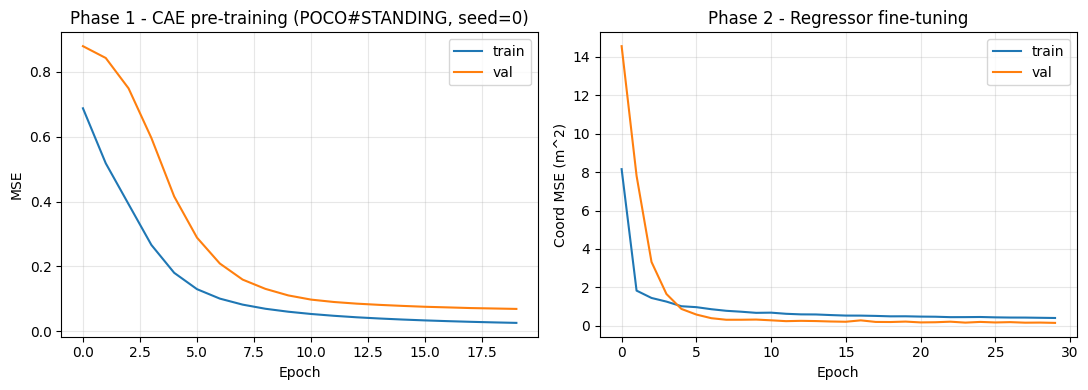

Saved figures: results/02_cnnloc_curves.{png,pdf}


In [6]:
# Plot training curves for the first (or only) configuration
train_key, seed, history = histories[0]
fig, axes = plt.subplots(2, 1, figsize=(7.0, 7.8))
axes[0].plot(history.pretrain_loss, label='train')
axes[0].plot(history.pretrain_val_loss, label='val')
axes[0].set_title(f'Fase 1 - Pre-entrenamiento CAE ({train_key}, semilla={seed})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE de reconstrucción')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.finetune_loss, label='train')
axes[1].plot(history.finetune_val_loss, label='val')
axes[1].set_title('Fase 2 - Ajuste fino del regresor')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE de coordenadas (m$^2$)')
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS / '02_cnnloc_curves.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS / '02_cnnloc_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved figures: results/02_cnnloc_curves.{png,pdf}')

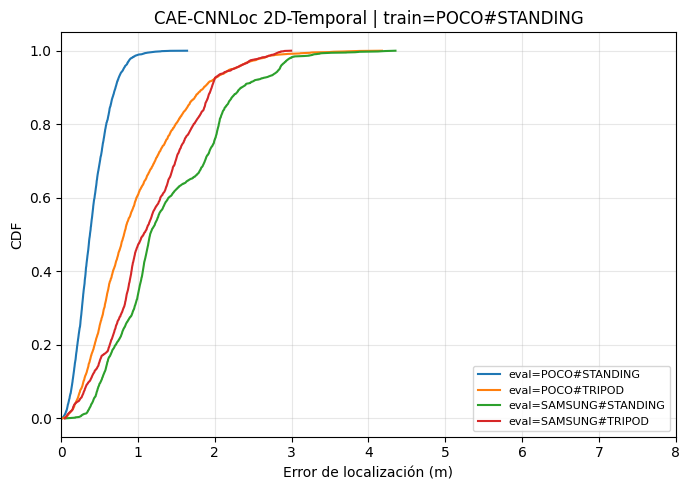

In [7]:
def plot_cdf(ax, errors, label, **kw):
    e = np.sort(np.asarray(errors))
    cdf = np.arange(1, len(e) + 1) / len(e)
    ax.plot(e, cdf, label=label, **kw)

fig, ax = plt.subplots(figsize=(7, 5))
for test_key in matrices:
    sub = df_cnn[(df_cnn['train_set'] == TRAIN_SUBSET_KEYS[0]) &
                  (df_cnn['test_set'] == test_key)]
    if not sub.empty:
        plot_cdf(ax, sub['error'], f'eval={test_key}', linewidth=1.5)
ax.set_xlim(0, 8)
ax.set_xlabel('Error de localización (m)')
ax.set_ylabel('CDF')
ax.set_title(f'CAE-CNNLoc 2D-Temporal | train={TRAIN_SUBSET_KEYS[0]}')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout()
fig.savefig(RESULTS / '02_cnnloc_cdf.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS / '02_cnnloc_cdf.pdf', bbox_inches='tight')
plt.show()